In [19]:
#install.packages("readr")
.libPaths(c("~/R/x86_64-pc-linux-gnu-library/4.1", .libPaths()))


In [20]:
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(tibble)
library(purrr)
library(ggrepel)
library(pheatmap)
library(tidyr)

#### 1. METADATA

In [21]:
# metadata check

metadata <- read_tsv("../../results_for_analysis/s_aureus_metadata.tsv", show_col_types = FALSE) |> 
    rename(
        sample = `Sequence file name`,
        date        = `Date of isolation`,
        sample_type = `Sample type`,
        host        = `Sample source`,
        region      = Region,
        animal_contact = `Human Contact with animals`,
        species     = Species,
        ST_meta     = ST
    )

# metadata overview

count(metadata, host)
count(metadata, region)
count(metadata, host, region) |>
    pivot_wider(names_from = region, values_from = n, values_fill = 0)

count(metadata, ST_meta, sort = TRUE)
count(metadata, sample_type, host)


metadata |>
     filter(host == "Human") |>
     count(animal_contact)




host,n
<chr>,<int>
Cow,43
Human,19


region,n
<chr>,<int>
Bagamoyo,26
D’Salaam,12
Morogoro,14
Tanga,10


host,Bagamoyo,Morogoro,Tanga,D’Salaam
<chr>,<int>,<int>,<int>,<int>
Cow,21,13,9,0
Human,5,1,1,12


ST_meta,n
<chr>,<int>
ST7846,12
ST152,11
ST97,9
ST5477,7
ST121,4
ST7841,4
ST7840,3
Unkown,3
ST7845,2


sample_type,host,n
<chr>,<chr>,<int>
Milk,Cow,43
Nasal swab,Human,19


animal_contact,n
<chr>,<int>
No,12
Yes,7


#### 2. QC PASSED ASSEMBLIES

In [22]:
passed_samples <- read_lines("../../results_for_analysis/sample_list_QC_passed.txt")

#### 3. KMERFINDER - quick species check

Rows: 62 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (6): Sample, # Sequence ID, Accession Number, Description, Taxonomy, Sp...
dbl (14): Num, Score, Expected, Template_length, Query_Coverage, Template_Co...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Sample"                "# Sequence ID"         "Num"                  
 [4] "Score"                 "Expected"              "Template_length"      
 [7] "Query_Coverage"        "Template_Coverage"     "Depth"                
[10] "tot_query_Coverage"    "tot_template_Coverage" "tot_depth"            
[13] "q_value"               "p_value"               "Accession Number"     
[16] "Description"           "TAXID"                 "Taxonomy"             
[19] "TAXID Species"         "Species"

Total isolates: 53 
Passed QC:      51 
Flagged:        2 

# A tibble: 2 × 4
  sample        query_cov template_cov depth
  <chr>             <dbl>        <dbl> <dbl>
1 R0051_BC00101      54.7         95.7  24.2
2 Q0003_BC00406      35.9         83.3  88.5


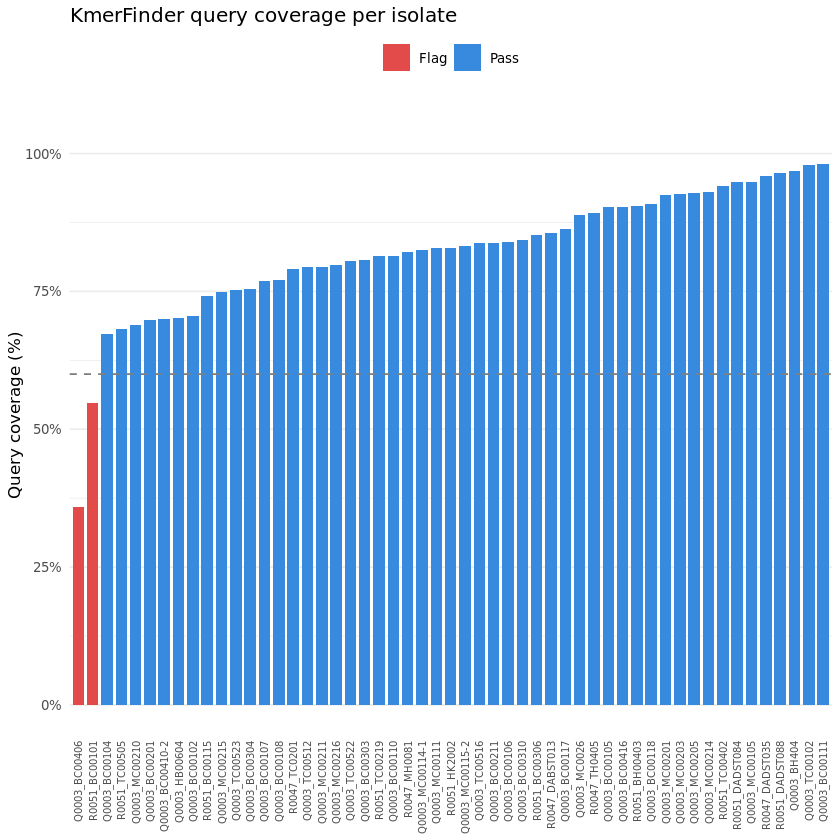

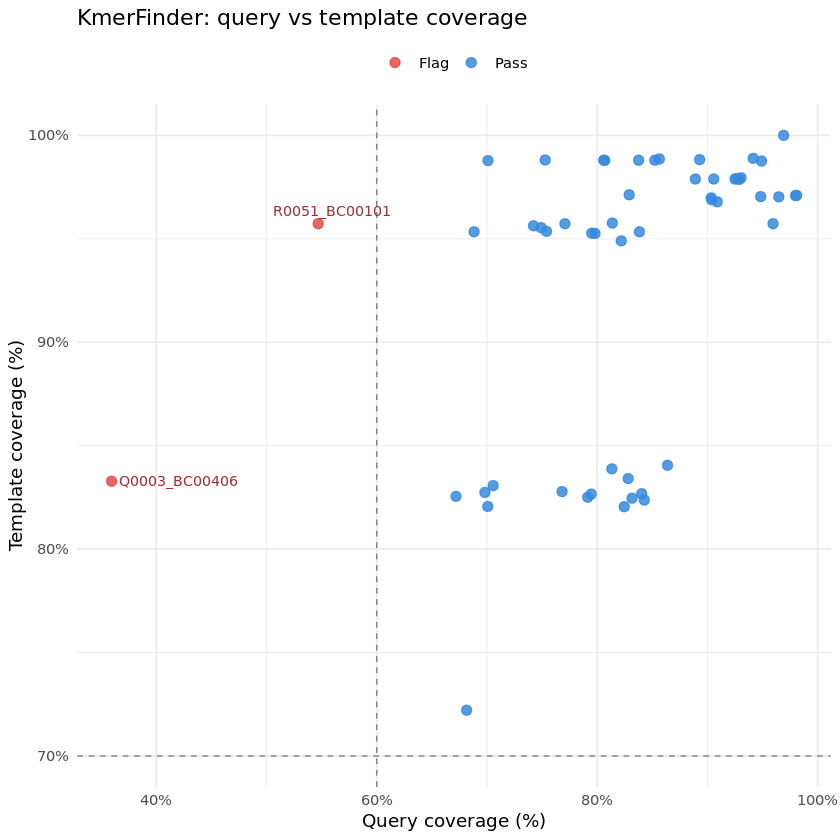

In [33]:
species_df <- read_tsv("../../results_for_analysis/kmerfinder/kmerfinder_for_trimmed_reads/kmerfinder_summary_1st_hit.txt")

# kmer - rapid species confirmation
colnames(species_df)
#species_df |> filter(Species != "Staphylococcus aureus")

species_df <- species_df |>
    filter(Sample %in% passed_samples)


# QC thresholds
QC_QUERY_COV  <- 60   # minimum query coverage %
QC_TEMPL_COV  <- 70   # minimum template coverage %

species_df <- species_df |>
  rename(
    sample          = Sample,
    query_cov       = Query_Coverage,
    template_cov    = Template_Coverage,
    depth           = Depth,
    description     = Description
  ) |>
  mutate(
    qc_pass = query_cov >= QC_QUERY_COV & template_cov >= QC_TEMPL_COV,
    label   = if_else(qc_pass, "Pass", "Flag")
  )

# summary
cat("Total isolates:", nrow(species_df), "\n")
cat("Passed QC:     ", sum(species_df$qc_pass), "\n")
cat("Flagged:       ", sum(!species_df$qc_pass), "\n\n")
print(species_df |> filter(!qc_pass) |> select(sample, query_cov, template_cov, depth))

# plot 1:
p1 <- species_df |>
  arrange(query_cov) |>
  mutate(sample = factor(sample, levels = sample)) |>
  ggplot(aes(x = sample, y = query_cov, fill = label)) +
  geom_col(width = 0.8) +
  geom_hline(yintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.5) +
  scale_fill_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_y_continuous(limits = c(0, 105), labels = function(x) paste0(x, "%")) +
  labs(x = NULL, y = "Query coverage (%)",
       title = "KmerFinder query coverage per isolate",
       fill = NULL) +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
        legend.position = "top",
        panel.grid.major.x = element_blank())



# plot 2
p2 <- species_df |>
  ggplot(aes(x = query_cov, y = template_cov, colour = label, label = sample)) +
  geom_point(size = 2.5, alpha = 0.85) +
  geom_vline(xintercept = QC_QUERY_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  geom_hline(yintercept = QC_TEMPL_COV, linetype = "dashed", colour = "grey50", linewidth = 0.4) +
  ggrepel::geom_text_repel(data = filter(species_df, !qc_pass),
                            size = 3, colour = "#A32D2D", max.overlaps = 10) +
  scale_colour_manual(values = c("Pass" = "#378ADD", "Flag" = "#E24B4A")) +
  scale_x_continuous(labels = function(x) paste0(x, "%")) +
  scale_y_continuous(labels = function(x) paste0(x, "%")) +
  labs(x = "Query coverage (%)", y = "Template coverage (%)",
       title = "KmerFinder: query vs template coverage",
       colour = NULL) +
  theme_minimal(base_size = 11) +
  theme(legend.position = "top")



p1
p2

#### 4. MLST RESULTS

In [35]:
# mlst typing 

mlst_df <- read_tsv("../../results_for_analysis/mlst/mlst_summary.txt", col_names = FALSE, show_col_types = FALSE)
colnames(mlst_df) <- c("sample", "species", "ST", "gene1", "gene2", "gene3", "gene4", "gene5", "gene6", "gene7")

mlst_df <- mlst_df |>
    mutate(sample = sample |>
        str_remove("^/home/projects/course_23262/group/group1/23262_infectious_disease_project/data/assemblies_QC_passed/") %>%
        str_remove("\\.fasta$")) |>
        filter(sample %in% passed_samples)

mlst_df |> count(ST, sort=TRUE)

ST,n
<chr>,<int>
7846,12
97,9
152,8
5477,6
7841,4
7840,3
121,2
7845,2
-,1


In [36]:
# compare metadata and mlst results

meta_vs_mlst <- metadata |>
  left_join(mlst_df |> select(sample, ST_mlst = ST), by = "sample") |>
  mutate(
    # normalise metadata ST: strip "ST" prefix, fix typos
    ST_meta_clean = str_remove(ST_meta, "^ST") |> str_trim(),
    ST_meta_clean = case_when(
      ST_meta_clean == "Unknown" ~ NA_character_,
      ST_meta_clean == "Unkown"  ~ NA_character_,   # typo in metadata
      TRUE                       ~ ST_meta_clean
    ),
    ST_mlst_clean = as.character(ST_mlst),
    # agreement check
    ST_match = case_when(
      is.na(ST_meta_clean)  ~ "meta_unknown",
      is.na(ST_mlst_clean)  ~ "mlst_missing",
      ST_mlst_clean == "-" ~ "mlst_missing",
      is.na(ST_meta_clean) & is.na(ST_mlst_clean) ~ "both_missing",
      ST_meta_clean == ST_mlst_clean ~ "match",
      TRUE                           ~ "mismatch"
    )
  )

#inspect
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# remove samples that didnt pass qc at assembly
# because i only ran resfinder with qc passed assemblies_QC_passed
meta_vs_mlst <- meta_vs_mlst |>
  filter(sample %in% passed_samples)

print("Inspection after filtering:")
#inspect again after filtering
count(meta_vs_mlst, ST_match)

meta_vs_mlst |>
  filter(ST_match == "mismatch") |>
  select(sample, ST_meta, ST_mlst, host, region)

# WELL THIS IS GOOD NEWS

ST_match,n
<chr>,<int>
match,52
meta_unknown,4
mlst_missing,6


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


[1] "Inspection after filtering:"


ST_match,n
<chr>,<int>
match,52
mlst_missing,1


sample,ST_meta,ST_mlst,host,region
<chr>,<chr>,<chr>,<chr>,<chr>


Here I checked the agreement between metadata and our mlst results.
Most are okay, and one is missing in mlst.
Good news!! The one missing in MLST can be either taken from metadata or left empty. Doesn't really matter I think
 

In [37]:
colnames(meta_vs_mlst)

[1] "sample"             "date"               "sample_type"       
 [4] "host"               "region"             "animal_contact"    
 [7] "species"            "ST_meta"            "Sequencing machine"
[10] "ST_mlst"            "ST_meta_clean"      "ST_mlst_clean"     
[13] "ST_match"

In [38]:
# resolve with mlst priority
final_strain_data <- meta_vs_mlst |>
    mutate(ST_final = case_when(
      ST_mlst_clean != "-"  ~ ST_mlst_clean,   # trust MLST first
      !is.na(ST_meta_clean)  ~ ST_meta_clean
     )) |> 
     select(-c(ST_meta, ST_meta_clean, ST_mlst_clean, ST_match, `Sequencing machine`))

count(final_strain_data, ST_final, sort = TRUE)


ST_final,n
<chr>,<int>
7846,12
97,9
152,8
5477,7
7841,4
7840,3
121,2
7845,2
22,1


We end up with 8 ST152 !!

#### 5. RESFINDER 

In [39]:
#load data
pheno <- read_tsv("../../results_for_analysis/resfinder/our_data/all_pheno_table.tsv", show_col_types = FALSE)
resfinder_df <- read_tsv("../../results_for_analysis/resfinder/our_data/all_resfinder_tab.tsv", show_col_types = FALSE)

colnames(resfinder_df)


Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”


[1] "Sample"                       "Resistance gene"             
 [3] "Identity"                     "Alignment Length/Gene Length"
 [5] "Coverage"                     "Position in reference"       
 [7] "Contig"                       "Position in contig"          
 [9] "Phenotype"                    "Accession no."

In [40]:
resfinder_filtered <- resfinder_df |> 
    select(c(Sample, `Resistance gene`, Phenotype, Identity, Coverage)) |>
    rename(
        sample = Sample,
        gene = `Resistance gene`,
        phenotype = Phenotype,
        coverage = Coverage,
        identity = Identity
    ) |>
    # remove duplicated genes per sample
    distinct()

# add back samples with no resistance genes
resfinder_filtered <- tibble(sample = passed_samples) |>
    left_join(resfinder_filtered, by = "sample")


In [41]:
# presence / absence matrix for the gene heatmap

pa_mat <- resfinder_filtered |>
    filter(!is.na(gene)) |>
    mutate(present = 1L) |>
    pivot_wider(id_cols = sample, names_from = gene,
                values_from = present, values_fill = 0L)

# add back samples with no genes
missing_samples <- setdiff(passed_samples, pa_mat$sample)

pa_mat <- pa_mat |>
    bind_rows(tibble(sample = missing_samples)) |>
    column_to_rownames("sample") |>
    as.matrix()



In [42]:
# build annotation

annot_row <- final_strain_data |>
    mutate(
      ST = paste0("ST", ST_final),
      region = iconv(region, from = "UTF-8", to = "ASCII//TRANSLIT") #idk encoding is a bitch
    ) |>
    select(sample, ST, host, region) |>
    arrange(ST, host) |>
    column_to_rownames("sample")



# match matrix row order to annotation
pa_mat <- pa_mat[rownames(annot_row), , drop=FALSE]

# create gaps between ST groups
gap_pos <- annot_row |>
  mutate(row_n = row_number()) |>
  group_by(ST) |>
  summarise(last = max(row_n), .groups = "drop") |>
  arrange(last) |>
  pull(last) |>
  head(-1)



In [43]:
# colors for heatmap

st_levels <- unique(annot_row$ST) |> sort()
st_cols <- setNames(
  colorRampPalette(c("#378ADD","#fa0606","#3B6D11","#BA7517",
                     "#534AB7","#0F6E56","#993556","#5F5E5A",
                     "#D85A30","#185FA5"))(length(st_levels)),
  st_levels
)

ann_colors <- list(
  ST = st_cols,
  host = c(
    "Cow" = "#a0d69c",    # choose any hex
    "Human" = "#c9937b"
  ),
  region = c(
    "Bagamoyo" = "#EEEDFE",
    "Morogoro" = "#AFA9EC",
    "Tanga" = "#7F77DD",
    "D\'Salaam" = "#3C3489"
  )
)

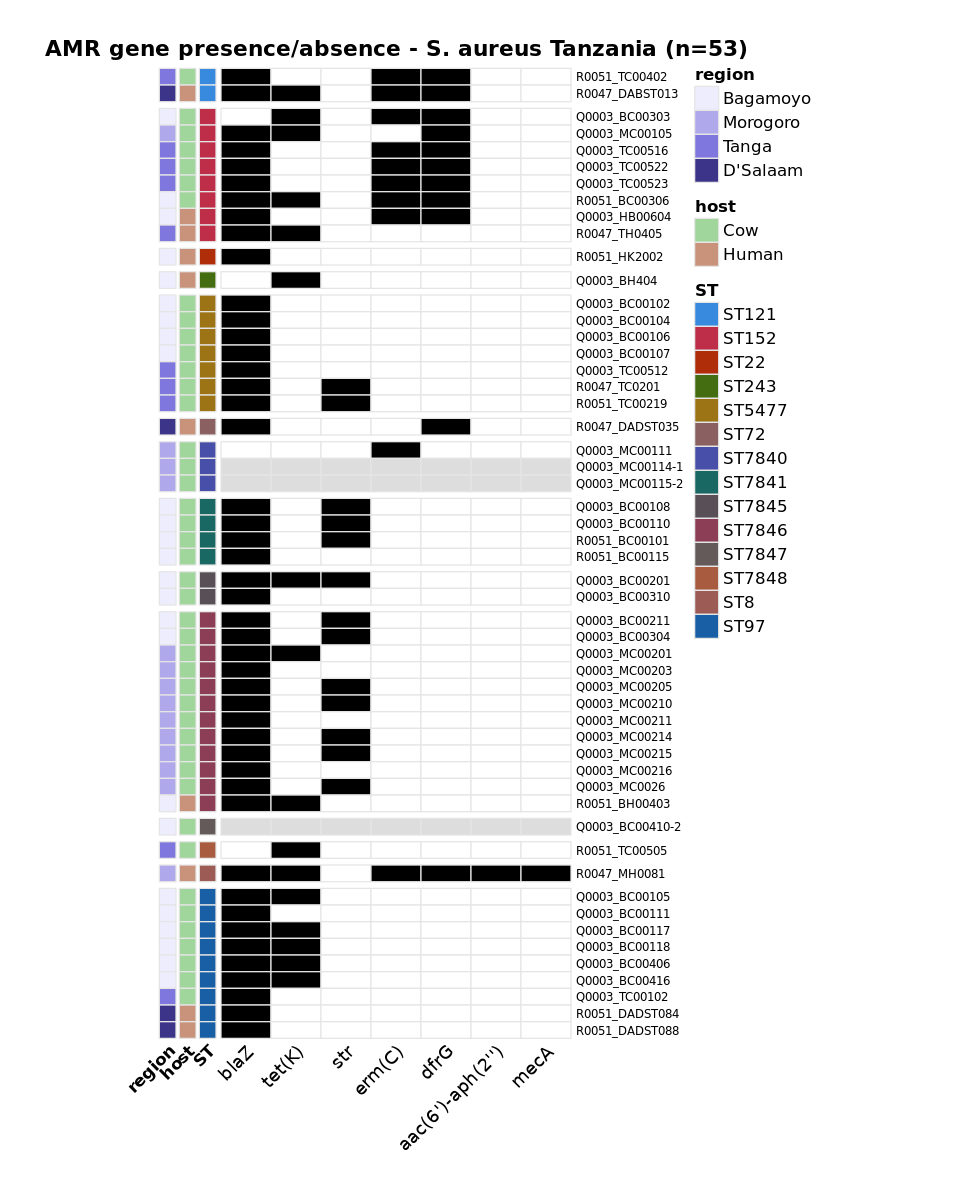

In [44]:
# heatmap. finally omg

options(repr.plot.width = 8, repr.plot.height = 10)


pheatmap(
  pa_mat,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("white", "black"),
  breaks            = c(-0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)",
  #          = "results/resfinder_heatmap.pdf",
  width             = 14,
  height            = 18
)

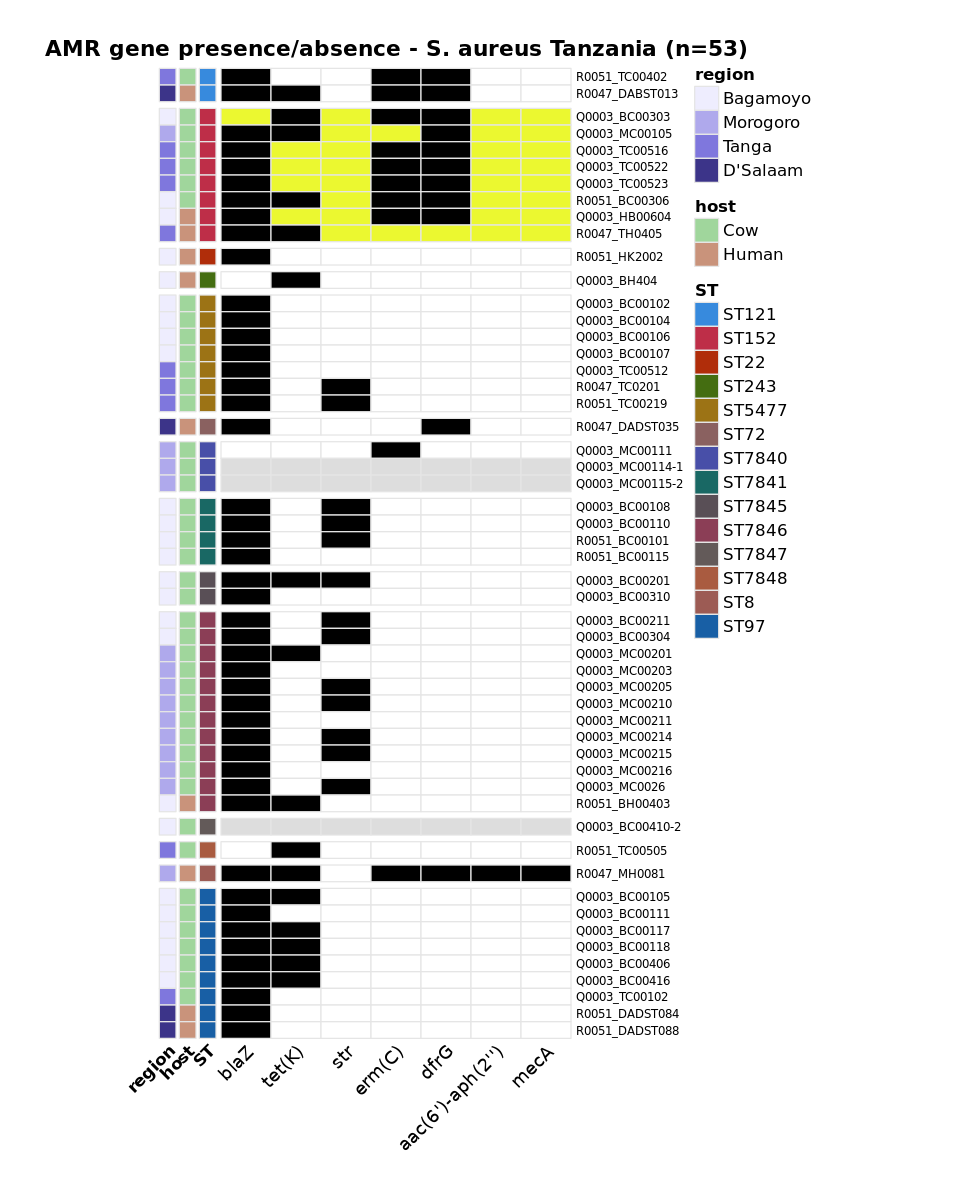

In [ ]:

# make ST152 emoty cells light yellow
pa_plot <- pa_mat
st152_rows <- rownames(annot_row)[annot_row$ST == "ST152"]

tmp <- pa_plot[st152_rows, , drop = FALSE]
tmp[tmp == 0] <- -1
pa_plot[st152_rows, ] <- tmp

pheatmap(
  pa_plot,
  annotation_row    = annot_row,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = FALSE,
  gaps_row          = gap_pos,
  color             = c("#ebf830", "white", "black"),  # ST152-0, other-0, 1
  breaks            = c(-1.5, -0.5, 0.5, 1.5),
  border_color      = "grey90",
  cellwidth         = 30,
  cellheight        = 10,
  fontsize_row      = 7,
  fontsize_col      = 11,
  angle_col         = 45,
  legend            = FALSE,
  main              = "AMR gene presence/absence - S. aureus Tanzania (n=53)"
)


We can already see this strain is more resistant!!!!